<div style="
    background-color:#119223  ; 
    padding: 20px;
    border-radius: 10px;
    color: #FBFCFB   ;
    text-align: center;
    ">
    <h1 style="font-size: 48px;
        font-weight: bold;
        "> CREDIT RISK PREDICTION NOTEBOOK </h1>
    <p style="font-size: 24px;
        font-weight: bold;
        margin-top: 20px;"></p>
</div>

## Learning Objectives
- 1: `import os` and  `import warnings`
- 2: A few things you want to know when you have a dataset
- 3: Use a heatmap to understand the correlations
- 4: Use a pair plot to understand the correlations
- 5: Use frequency charts
- 6: Only using training data to do EDA
- 7: How to develop a function for reuse
- 8: Write into a for loop
- 9: Interpretation is crucial
- 10: Use `pd.qcut()`
- 11: Create new categorical variables
- 12: A fun learning objective `<div style="...">`
- 13: A fun learning objective `<a id='this_tag'></a>` 

## (1) Import libraries

In [ ]:
#!pip install scikit-learn pandas numpy matplotlib seaborn plotly pycaret

In [1]:
# data
import pandas as pd
import numpy as np

# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#import missingno as msno
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
#from wordcloud import WordCloud

# styling
%matplotlib inline
sns.set_style('darkgrid')
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'

import os 
#from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

#### Learning objective 1: `import os` and  `import warnings` 
- You use `import os` in Python when you need to interact with the operating system. The os module provides a way of using operating system-dependent functionality like file and directory manipulation, environment variable access, and process management in a platform-independent manner.
- You use `import warnings` to suppress all warning messages. Warnings are used to inform the developer of potentially problematic situations.


## (2) Load the dataset

In [2]:
# Download the dataset from https://www.kaggle.com/datasets/laotse/credit-risk-dataset?resource=download
path = '/Users/chriskuo/Downloads/data'
data =  pd.read_csv(path + "/credit_risk_dataset.csv") 

# Print sample
data.head()  # You can also use data.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


FEATURE DESCRIPTIONS
- **loan_status**: This is the target variable, where 0 indicates non-default and 1 indicates default.
    - 0: Non-default - The borrower successfully repaid the loan as agreed, and there was no default.
    - 1: Default - The borrower failed to repay the loan according to the agreed-upon terms and defaulted on the loan.
- **person_age**: Age of the individual applying for the loan.
- **person_income**: Annual income of the individual.
- **person_home_ownership**: Type of home ownership of the individual.
    - rent: The individual is currently renting a property.
    - mortgage: The individual has a mortgage on the property they own.
    - own: The individual owns their home outright.
    - other: Other categories of home ownership that may be specific to the dataset.
- **person_emp_length**: Employment length of the individual in years.
- **loan_intent**: The intent behind the loan application.
- **loan_grade**: The grade assigned to the loan based on the creditworthiness of the borrower.
    - A: The borrower has a high creditworthiness, indicating low risk.
    - B: The borrower is relatively low-risk, but not as creditworthy as Grade A.
    - C: The borrower's creditworthiness is moderate.
    - D: The borrower is considered to have higher risk compared to previous grades.
    - E: The borrower's creditworthiness is lower, indicating a higher risk.
    - F: The borrower poses a significant credit risk.
    - G: The borrower's creditworthiness is the lowest, signifying the highest risk.
- **loan_amnt**: The loan amount requested by the individual.
- **loan_int_rate**: The interest rate associated with the loan.
- **loan_percent_income**: The percentage of income represented by the loan amount.
- **cb_person_default_on_file**: Historical default of the individual as per credit bureau records.
    - Y: The individual has a history of defaults on their credit file.
    - N: The individual does not have any history of defaults.
- **cb_preson_cred_hist_length**: The length of credit history for the individual.

## (3) Understand the data
#### Learning objective 2: A few things you want to know when you have a dataset 
- How many records and columns?
- What are the categorical and numerical fields?
- What do the distributions look like?

In [3]:
data.shape

(32581, 12)

In [4]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
cat_var = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']
num_var = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']   
target='loan_status'

In [6]:
data.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
data.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

In [8]:
data['loan_status'].value_counts() 

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [9]:
data['loan_intent'].value_counts() 

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [10]:
data['loan_grade'].value_counts() 

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

In [11]:
data['cb_person_default_on_file'].value_counts() 

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

In [12]:
data.duplicated().sum()

165

In [13]:
num_var = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_status','loan_percent_income','cb_person_cred_hist_length']   

In [14]:
data[num_var].corr()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


### (3.1) Heatmap
#### Learning objective 3: Use a heatmap to understand the correlations
- https://medium.com/analytics-vidhya/love-the-ocean-love-seaborn-2e8737bef728?sk=2a265083a6501f97fd83c912761411ad

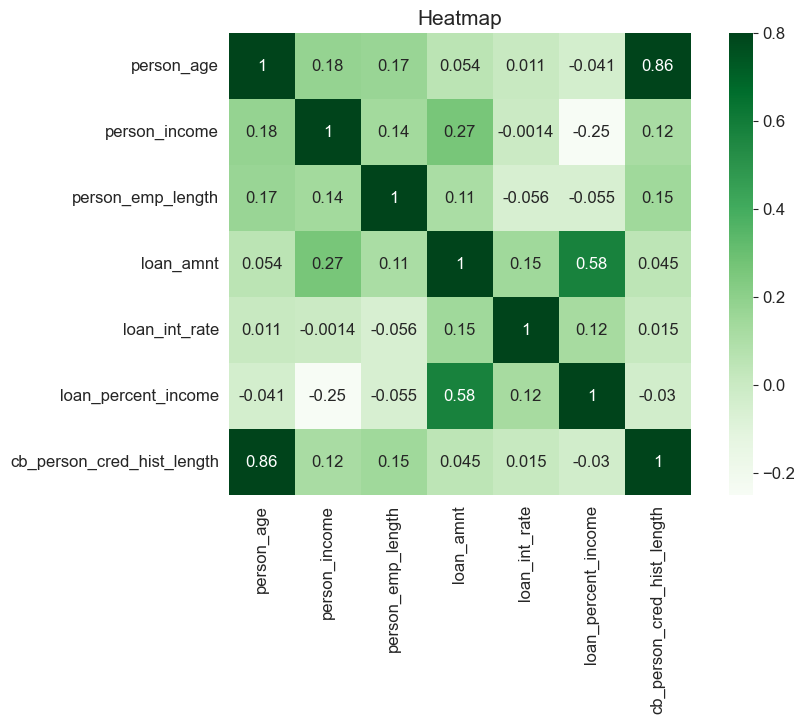

In [231]:
fig, ax = plt.subplots() 
fig.set_size_inches(10,6)
sns.heatmap(data[num_var].corr(), vmax =.8, square = True, annot = True,cmap='Greens' )
plt.title('Heatmap',fontsize=15);
plt.show()

### (3.2) Pair plot
#### Learning objective 4: Use a pair plot to understand the correlations

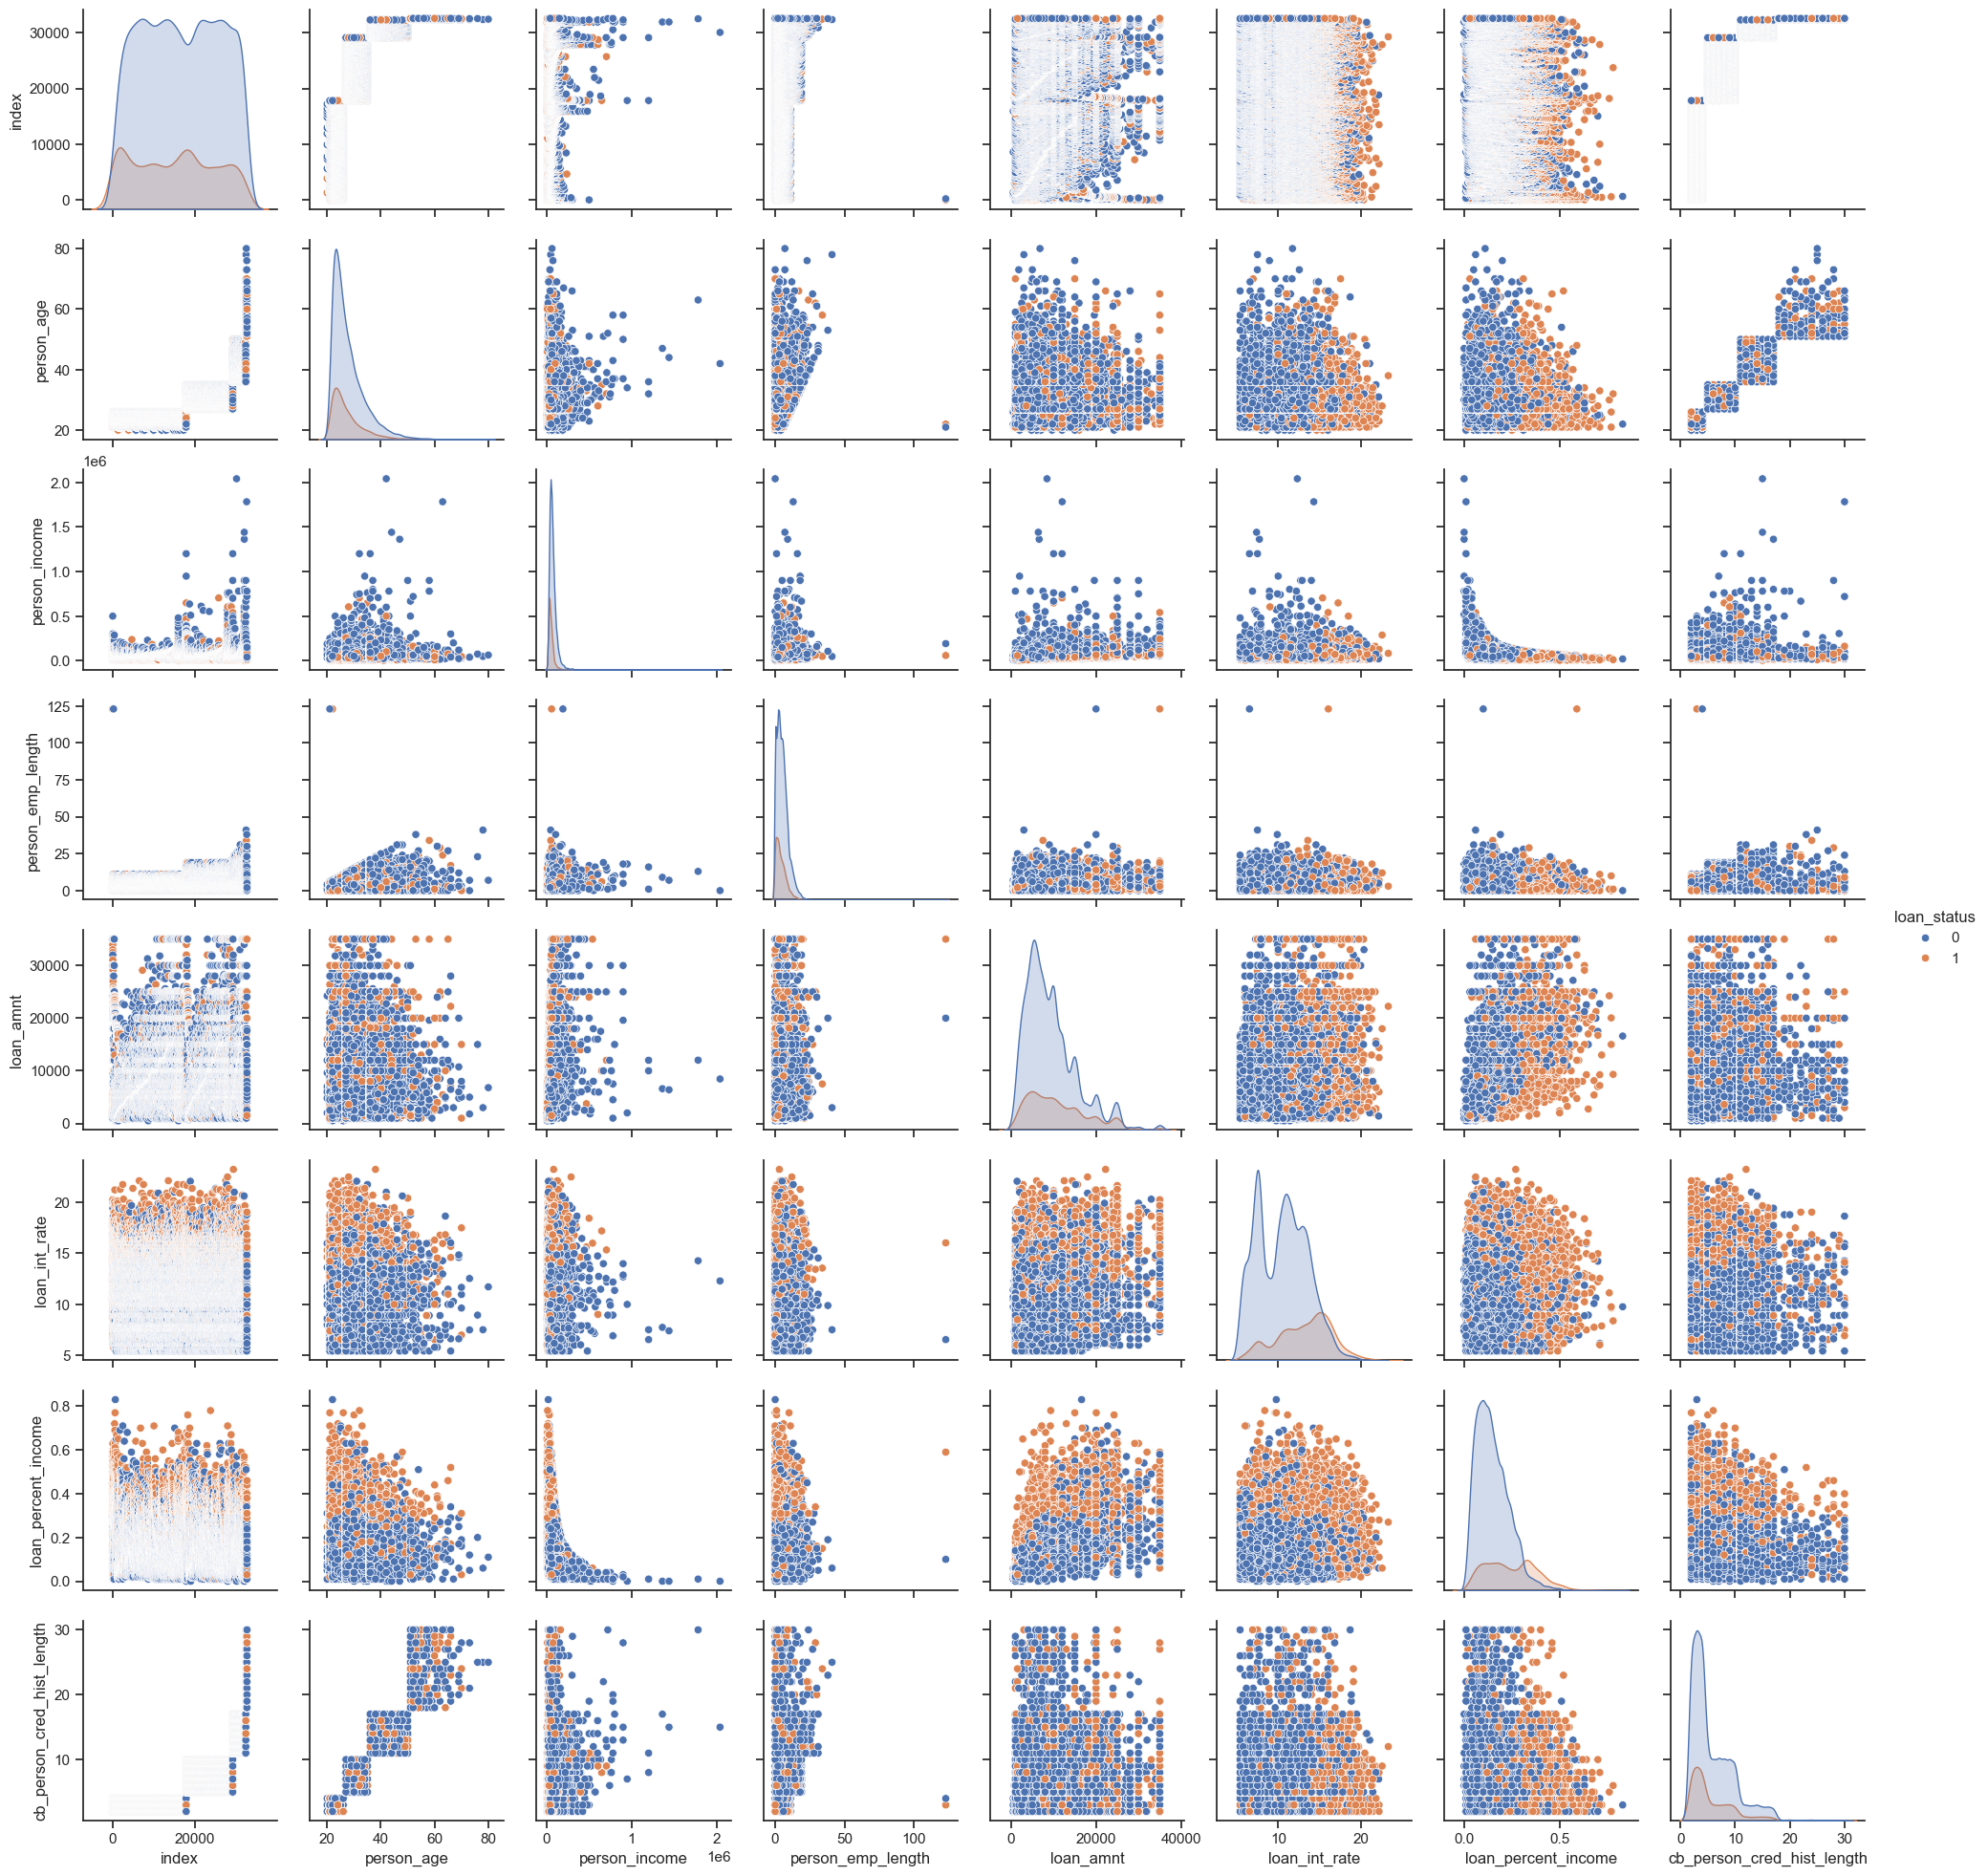

In [244]:
sns.pairplot(data,hue=target)

### (3.3) Frequency plot
#### Learning objective 5: Use frequency charts 
- Especially pay attention to any **extreme values (outliers)**

<Axes: xlabel='person_age', ylabel='Count'>

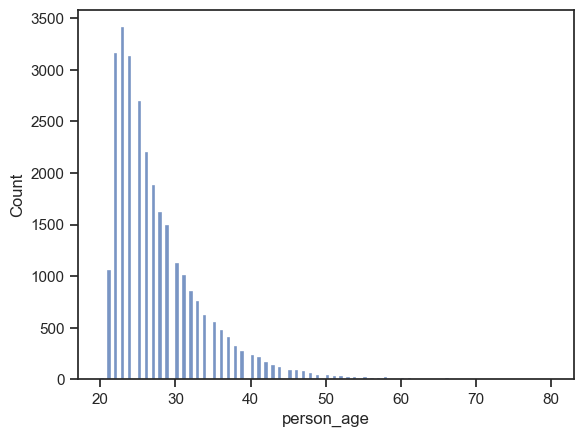

In [245]:
sns.histplot(data[num_var[0]]) 

<Axes: xlabel='person_income', ylabel='Count'>

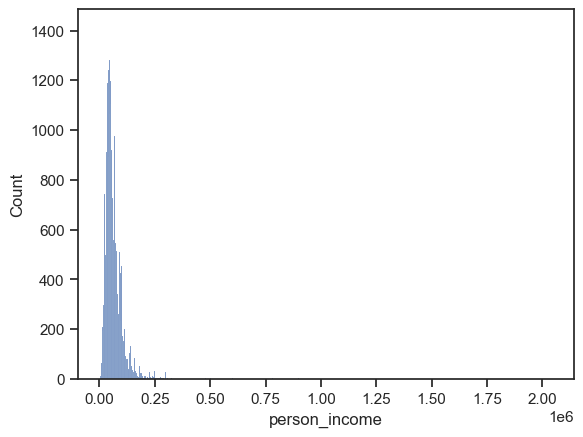

In [246]:
sns.histplot(data[num_var[1]]) 

<Axes: xlabel='person_emp_length', ylabel='Count'>

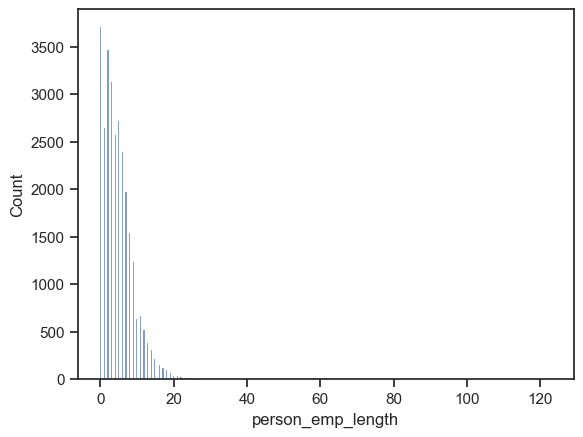

In [247]:
sns.histplot(data[num_var[2]]) 

<Axes: xlabel='loan_amnt', ylabel='Count'>

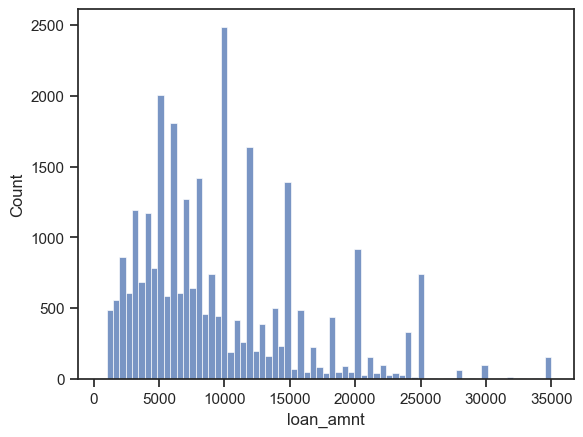

In [248]:
sns.histplot(data[num_var[3]]) 

<Axes: xlabel='loan_int_rate', ylabel='Count'>

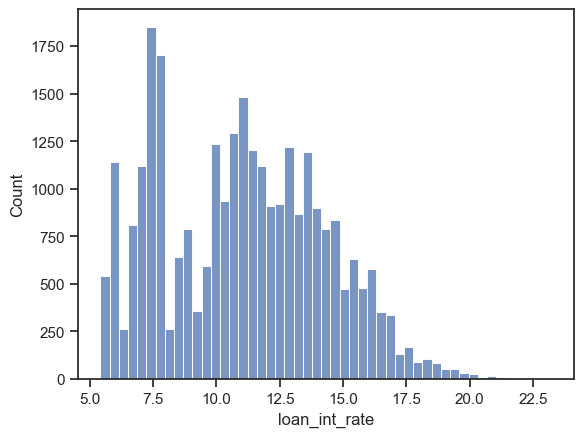

In [249]:
sns.histplot(data[num_var[4]]) 

<Axes: xlabel='loan_percent_income', ylabel='Count'>

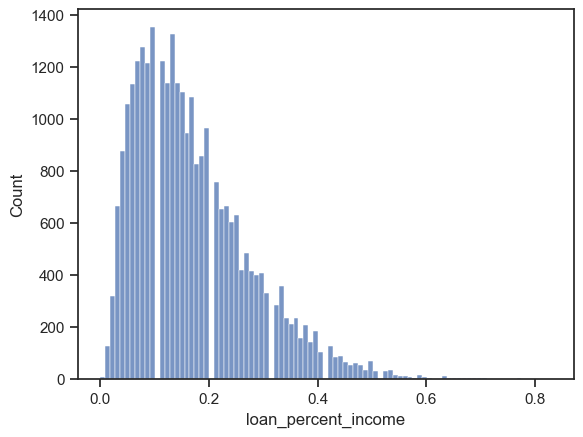

In [250]:
sns.histplot(data[num_var[5]]) 

<Axes: xlabel='cb_person_cred_hist_length', ylabel='Count'>

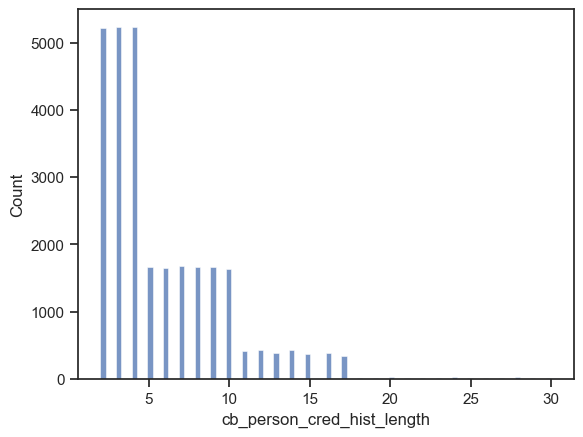

In [251]:
sns.histplot(data[num_var[6]]) 

## (4) EDA: Y by X 
- An extremely important chart in a supervised learning model

### (4.1) Split the data
#### Learning objective 6: Only using training data to do EDA

In [113]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, random_state=0)
[train.shape,test.shape]

[(21478, 13), (7160, 13)]

### (4.2) step-by-step coding
#### Learning objective 7: How to develop a function for reuse
- Print out every step

In [195]:
# Calculate the statistics
z= train.groupby('person_home_ownership')[target].agg(['count','mean']).reset_index() 
z['count_pcnt'] = z['count']/z['count'].sum()
z

,person_home_ownership,count,mean,count_pcnt
0,MORTGAGE,8840,0.125226,0.411584
1,OTHER,71,0.267606,0.003306
2,OWN,1659,0.060277,0.077242
3,RENT,10908,0.315182,0.507869


In [198]:
x = z['person_home_ownership']
bar_values =z['count_pcnt']
line_values = z['mean']
x_label = z.columns[0]
x_label

'person_home_ownership'

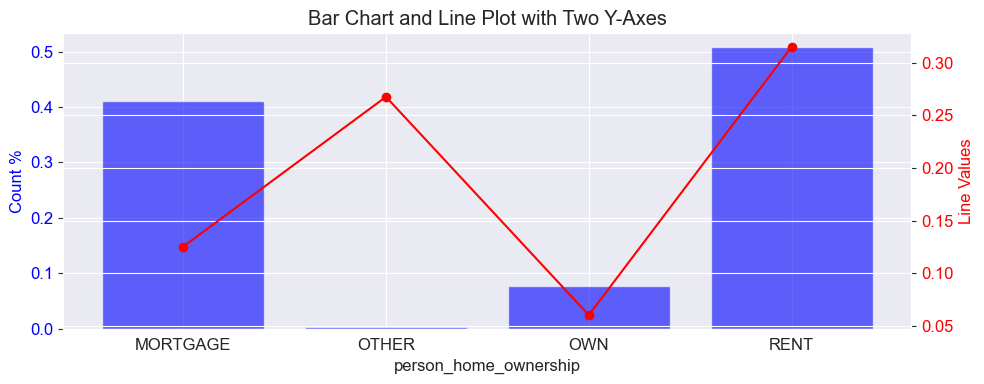

In [199]:
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot the bar chart on the primary y-axis
ax1.bar(x, bar_values, color='b', alpha=0.6, label='Bar Chart')
ax1.set_xlabel(x_label)
ax1.set_ylabel('Count %', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a secondary y-axis and plot the line chart
ax2 = ax1.twinx()  # This creates a second y-axis sharing the same x-axis
ax2.plot(x, line_values, color='r', marker='o', label='Line Chart')
ax2.set_ylabel('Line Values', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add a title and show the plot
plt.title('Bar Chart and Line Plot with Two Y-Axes')
fig.tight_layout()  # Adjust layout to make room for both y-axis labels
plt.show()

### (4.3) Make into a function
#### Learning objective 8: Write into a loop

In [200]:
def Y_by_X(df,var):
    # Calcuate the statistics
    z= train.groupby(var)[target].agg(['count','mean']).reset_index() 
    z['count_pcnt'] = z['count']/z['count'].sum()
    #x = z[var]
    x = z.iloc[:,0] # Or you can write this way: get the first column
    bar_values =z['count_pcnt']
    line_values = z['mean']
    x_label = z.columns[0]
    
    # Create a figure and axis
    fig, ax1 = plt.subplots(figsize=(10, 4))
    
    # Plot the bar chart on the primary y-axis
    ax1.bar(x, bar_values, color='b', alpha=0.6, label='Bar Chart')
    ax1.set_ylim(0,1)
    ax1.set_xlabel(x_label)
    ax1.set_ylabel('Count %', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    
    # Create a secondary y-axis and plot the line chart
    ax2 = ax1.twinx()  # This creates a second y-axis sharing the same x-axis
    ax2.plot(x, line_values, color='r', marker='o', label='Line Chart')
    ax2.set_ylim(0,1)
    ax2.set_ylabel(str(target), color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    fig.tight_layout()  # Adjust layout to make room for both y-axis labels
    plt.show()

#### Learning objective 9: Interpretation is crucial
- Interpret any business or economic meaning between X and Y. This is the most important step.

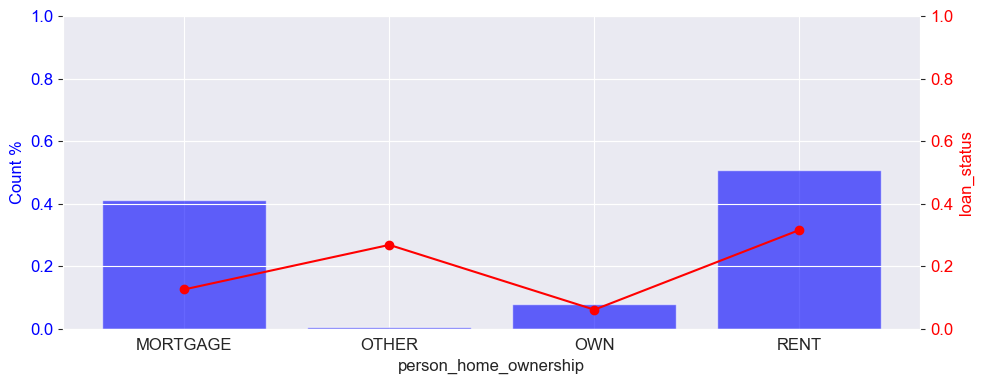

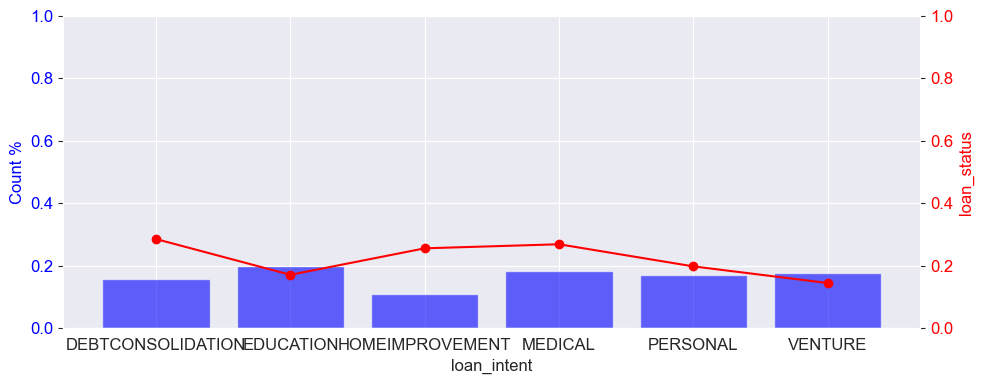

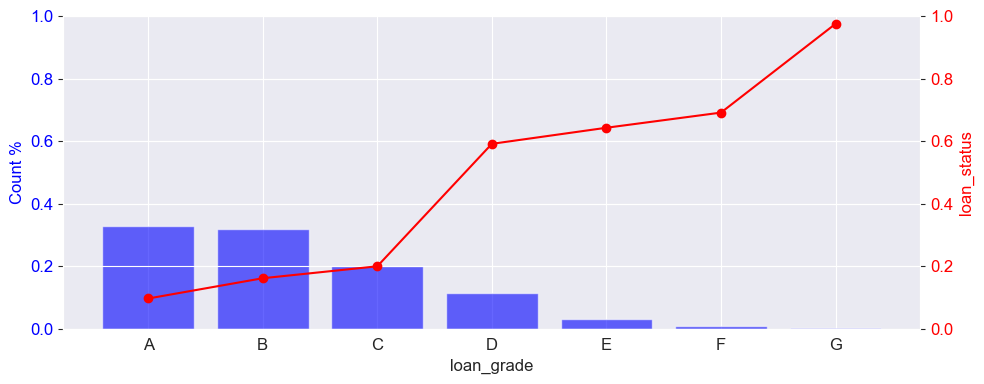

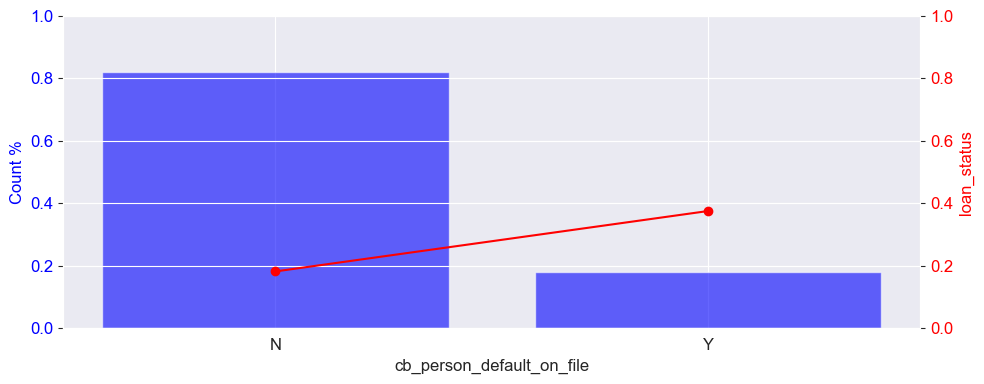

In [201]:
for var in cat_var:
    Y_by_X(train,var)

### (4.4) Bin a continous variable to categorical
#### Learning objective 10: Use `pd.qcut()` 
- Check if there is any NA or special values.
- Use Pandas' pd.qcut() to cut a continous variable.
- pd.qcut() can bin a continous variable into appropriate intervals for interpretation.

In [209]:
var = 'person_emp_length'
train[var].value_counts(dropna=False)[0:10]

person_emp_length
0.0     2785
2.0     2546
3.0     2317
5.0     2059
1.0     1984
4.0     1930
6.0     1798
7.0     1511
8.0     1151
9.0      918
11.0     499
10.0     486
Name: count, dtype: int64

- Convert the numerical variable 'var' into a categorical 'var_D'

In [210]:
var_D = pd.qcut(train[var],5,duplicates='drop').astype(str) 
var_D 

3834        (5.0, 8.0]
22109       (1.0, 3.0]
13864       (1.0, 3.0]
23766     (8.0, 123.0]
14348       (3.0, 5.0]
             ...      
13123       (5.0, 8.0]
19648    (-0.001, 1.0]
9845     (-0.001, 1.0]
10799       (3.0, 5.0]
2732        (5.0, 8.0]
Name: person_emp_length, Length: 21478, dtype: object

In [211]:
var_D.unique()

array(['(5.0, 8.0]', '(1.0, 3.0]', '(8.0, 123.0]', '(3.0, 5.0]',
       '(-0.001, 1.0]'], dtype=object)

In [212]:
z = train.groupby(var_D)[target].agg(['count','mean']).reset_index() 
z['count_pcnt'] = z['count']/z['count'].sum()

In [213]:
x = z.iloc[:,0] # Or you can write this way: get the first column
x   

0    (-0.001, 1.0]
1       (1.0, 3.0]
2       (3.0, 5.0]
3       (5.0, 8.0]
4     (8.0, 123.0]
Name: person_emp_length, dtype: object

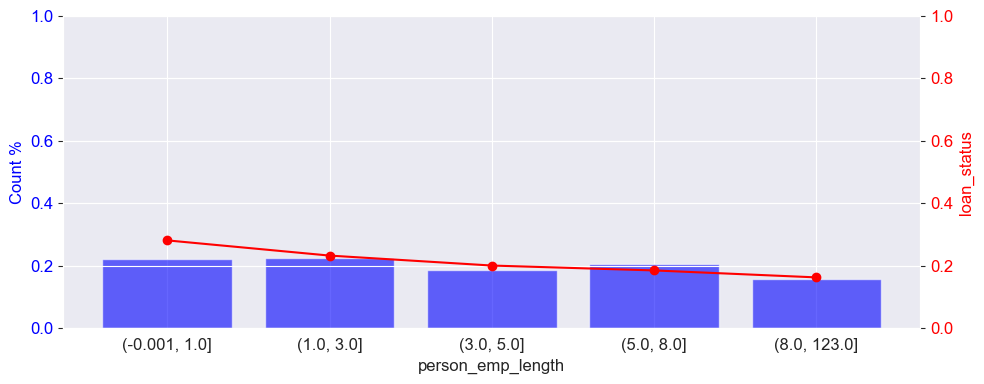

In [214]:
Y_by_X(train,var_D)

#### Learning objective 11: Create new categorical variables
- Create a new set of categorical variables without overwriting the original variables

In [228]:
num_var_D = []
for var in num_var:
    num_var_D.append(var + '_D')
    train[var+'_D'] = pd.qcut(train[var],5,duplicates='drop').astype(str) 
num_var_D

['person_age_D',
 'person_income_D',
 'person_emp_length_D',
 'loan_amnt_D',
 'loan_int_rate_D',
 'loan_percent_income_D',
 'cb_person_cred_hist_length_D']

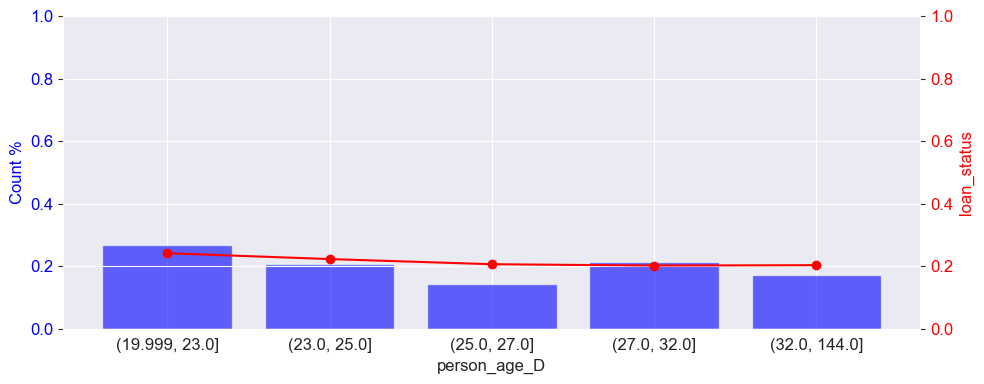

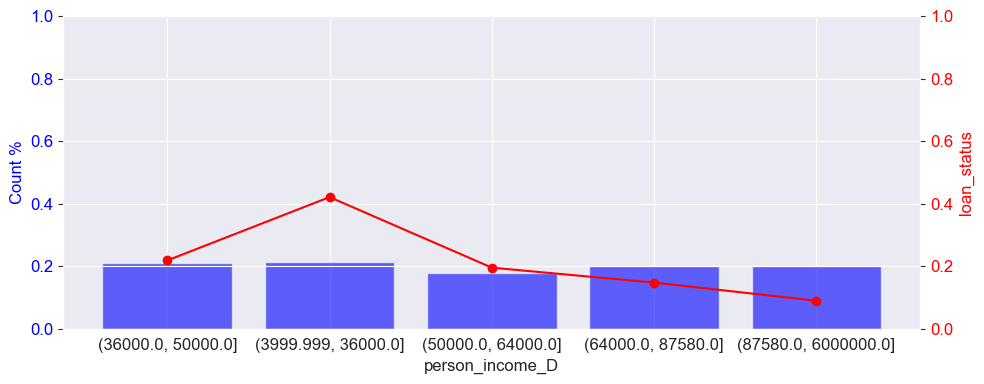

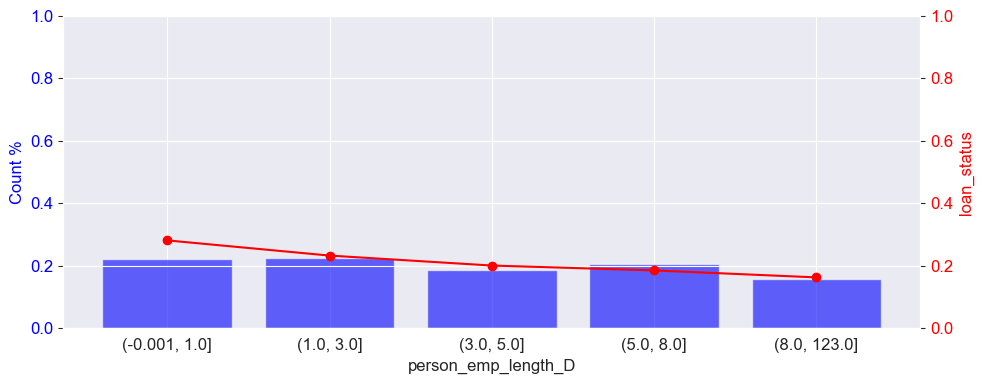

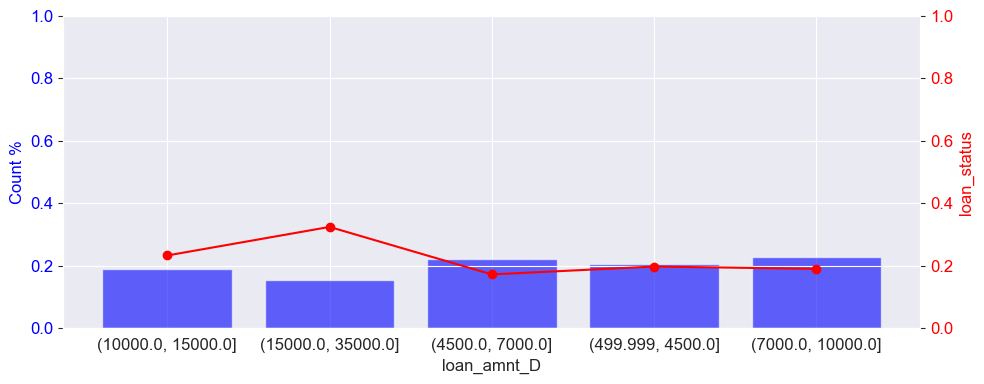

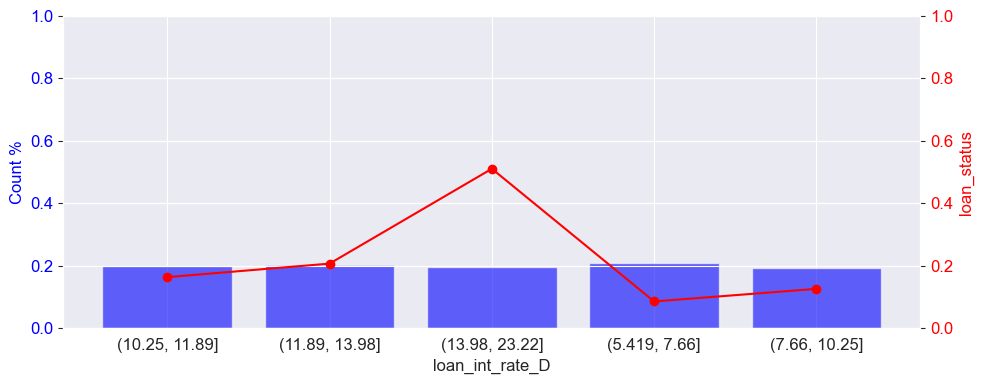

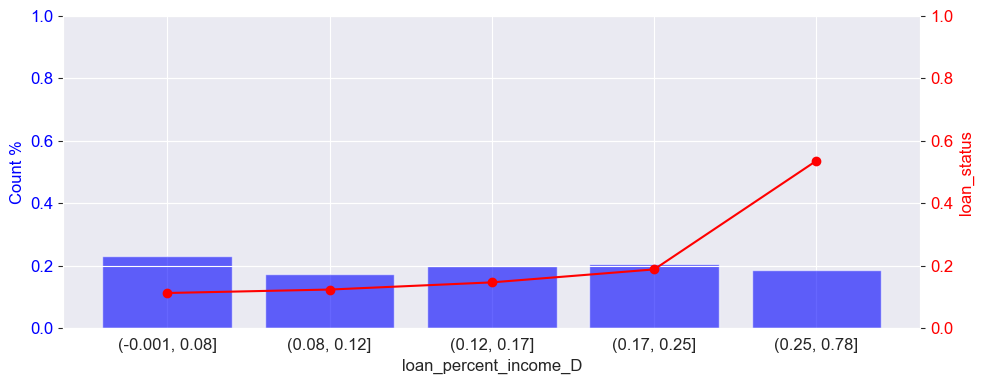

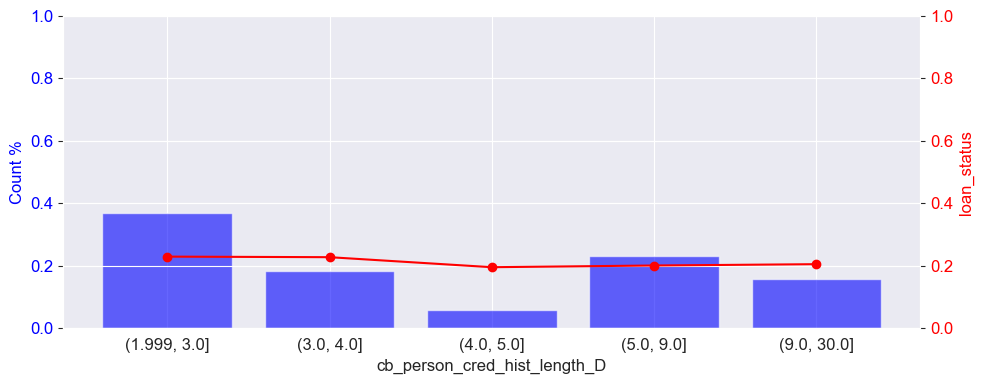

In [229]:
for var in num_var_D:
    Y_by_X(train,var)

#### Fun learning objective 12:  `<div style="...">`

Are you interested in making your notebook nice and appealing?

- When you see an HTML element like `<div style="...">`, it indicates that inline CSS styles are being applied directly to the `<div>` element. 
- Inline CSS allows you to define CSS properties for that specific element without using an external or internal stylesheet.

The title box is:
```html
<div style="
    background-color: #EFFE08; 
    padding: 20px;
    border-radius: 10px;
    color: #161A17    ;
    text-align: center;
    ">
    <h1 style="font-size: 48px;
        font-weight: bold;
        "> CREDIT RISK PREDICTION NOTEBOOK </h1>
    <p style="font-size: 24px;
        font-weight: bold;
        margin-top: 20px;"></p>
</div>
```

- **`<div>`**:
   - The `div` is a block-level container element, often used to group content or other elements together.

- **`style="..."`**:
   - The `style` attribute contains the CSS rules applied to the `<div>` element.
   - Each CSS property inside the `style` attribute is written in the format:
     ```css
     property: value;
     ```
   - Multiple properties are separated by semicolons (`;`).
- **`background-color: lightblue;`**:
  Sets the background color of the `div` to light blue.
- **`padding: 10px;`**:
  Adds 10 pixels of inner spacing around the content inside the `div`.
- **`border: 1px solid black;`**:
  Creates a 1-pixel-wide solid black border around the `div`.

1. You choose any color from https://htmlcolorcodes.com.
2. Copy the hex code of the color.


#### Fun learning objective 13: `<a id='this_tag'></a>` 

`<a id='this_tag'></a>` is an HTML element that defines an anchor (bookmark) tag with an `id` attribute. 
1. Named Anchor (Bookmark):
   - The `id='this_tag'` assigns an identifier to this anchor.
   - This allows other parts of the page (or external links) to navigate to this specific location using a URL fragment like `#this_tag`.

2. Navigation Example:
   - If you have a link like this:
     ```html
     <a href="#top">Go to top</a>
     ```
     Clicking this link will scroll the browser to the location of the `<a id='top'></a>` element.